# 💿 Подключение к Google Drive

Перед началом работы необходимо подключить Google Drive. Установите значение переменной PROJECT:

## Метод 1, через Secret:

1. В левой панели перейдите на вкладку "Ключ" (🔑)
2. Добавьте следующие секрет:
    - `PROJECT`: `/content/drive/<путь к папке на Google Drive>`

## Метод 2, напрямую в ячейке с кодом:

`PROJECT = '/content/drive/<путь к папке на Google Drive>'`

После этого запустите ячейку с кодом.

In [ ]:
# Mount Google Drive and setup paths
PROJECT = ''

if PROJECT == '':
    try:
      from google.colab import userdata
      PROJECT = userdata.get('PROJECT')
    except:
      print('Секрет PROJECT не установлен')
      raise

if str.isspace(PROJECT) or PROJECT == '':
  raise Exception("Не удалось установить значение переменной PROJECT")

from google.colab import drive
drive.mount('/content/drive')

# Add src directory to Python path
import sys
if f'{PROJECT}/src' not in sys.path:
    sys.path.insert(0, f'{PROJECT}/src')

# Change to project directory
%cd {PROJECT}

# Verify path is added
import os
print(f"✅ Added to sys.path: {PROJECT}/src")
print(f"📁 Current directory: {os.getcwd()}")
print(f"🔍 Available modules in src: {os.listdir('src') if os.path.exists('src') else 'src not found'}")

!pip -q install -U pip
!pip -q install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/Othercomputers/Ноутбук/training
✅ Added to sys.path: /content/drive/Othercomputers/Ноутбук/training/src
📁 Current directory: /content/drive/Othercomputers/Ноутбук/training
🔍 Available modules in src: ['analysis', 'data', 'models', 'training', 'utils', '__init__.py', '__pycache__', 'config.py']


# 🔑 Настройка переменных окружения

Перед запуском блокнота необходимо настроить переменные окружения:

1. Перейдите к иконке ключа (🔑) в левой боковой панели
2. Добавьте следующие секреты:
   - `SUPABASE_URL`: URL вашего проекта Supabase
   - `SUPABASE_PUBLISHABLE_KEY`: Ваш анонимный ключ Supabase
   - `EMAIL`: Ваш email для входа
   - `PASSWORD`: Ваш пароль для входа

# ⚙️ Конфигурация

## Установка путей

- LMDB_PATH: путь к файлу .lmdb - итоговый датасет
- MAP_PATH: путь к файлу .json - словарь для соответствия подписи в lmdb и её записи в базе данных

In [ ]:
# Установка путей
LMDB_PATH = '/content/drive/MyDrive/datasets/v2.lmdb'
MAP_PATH = '/content/drive/MyDrive/datasets/v2.json'

# Фильтрация подписей при создании датасета
INPUT_TYPE = 'any'  # Фильтр по типу ввода: 'any', 'mouse', 'touch', или 'pen'

In [ ]:
# 🚀 Обучение
OUTPUT_DIR = "/content/drive/MyDrive/runs"

# FEATURE_PIPELINE = [
#     "x", "y", "p", "t",
#     "vx", "vy", "ax", "ay", "prate", "path_tangent_angle", "abs_delta_pressure"
# ]

from config import DatasetConfig, ModelConfig, TrainingConfig
from training import TrainingRunner

# Dataset configuration
ds_cfg = DatasetConfig(
    lmdb_path = LMDB_PATH,
    # feature_pipeline = FEATURE_PIPELINE,
    dataset_sample_ratio = 1
)

# Model configuration
model_cfg = ModelConfig(

)

# Training configuration
train_cfg = TrainingConfig(
  output_dir = OUTPUT_DIR,
  epochs = 100,
  run_name = None,
  resume = True
)

print("🚀 Starting Hybrid Model Training\n")

try:
    runner = TrainingRunner(
        dataset_cfg=ds_cfg, model_cfg=model_cfg, train_cfg=train_cfg
    )
    runner.run()

    print("\n" + "=" * 80)
    print("✅ Training completed successfully!")
    print("=" * 80)

except KeyboardInterrupt:
    print("\n⚠️ Training interrupted by user")

except Exception as e:
    print("\n" + "=" * 80)
    print("❌ Training failed with error:")
    print("=" * 80)
    print(f"\n{type(e).__name__}: {e}\n")
    import traceback

    traceback.print_exc()
    exit(1)

🚀 Starting Hybrid Model Training

Starting training run...
2025-11-10 14:02:10 - INFO - ===== Session start: 2025-11-10 14:02:10 =====
2025-11-10 14:02:10 - INFO - Metrics will be logged to: /content/drive/MyDrive/runs/20251110_140210/logs/epoch_metrics.csv
2025-11-10 14:02:10 - INFO - Starting training run: 20251110_140210
2025-11-10 14:02:10 - INFO - Device: cuda
2025-11-10 14:02:10 - INFO - Checkpoint dir: /content/drive/MyDrive/runs/20251110_140210/checkpoints
2025-11-10 14:02:10 - INFO - Log dir: /content/drive/MyDrive/runs/20251110_140210/logs
2025-11-10 14:02:10 - INFO - Plot dir: /content/drive/MyDrive/runs/20251110_140210/plots
2025-11-10 14:02:10 - INFO - ================================================================================
2025-11-10 14:02:10 - INFO - FULL CONFIGURATION DUMP
2025-11-10 14:02:10 - INFO - ================================================================================
2025-11-10 14:02:10 - INFO - DatasetConfig:
2025-11-10 14:02:10 - INFO -   lmdb_pa

train: 100%|██████████| 115/115 [00:47<00:00,  2.40batch/s, GradNorm=0.8514, LR=0.000038, Loss=0.2926, Triplets=448, VRAM=0.08/0.60GB]


2025-11-10 14:03:00 - INFO - Epoch completed: 115/115 batches
2025-11-10 14:03:00 - INFO - Average loss: 0.2914
2025-11-10 14:03:00 - INFO - Average gradient norm: 0.7388
2025-11-10 14:03:00 - INFO - Average triplets per batch: 461.4
2025-11-10 14:03:00 - INFO - Total time: 48.02s
2025-11-10 14:03:00 - INFO - Starting validation...
2025-11-10 14:03:00 - INFO - Starting evaluation with 39 batches



eval: 100%|██████████| 39/39 [00:10<00:00,  3.69it/s, VRAM=0.08/0.76GB]


2025-11-10 14:03:11 - INFO - Evaluation completed: 2450 samples


...

train:  58%|█████▊    | 67/115 [00:28<00:18,  2.62batch/s, GradNorm=1.6010, LR=0.000600, Loss=0.2718, Triplets=448, VRAM=0.08/0.76GB]

2025-11-10 14:14:03 - ERROR - Batch 67: Invalid gradient norm inf
2025-11-10 14:14:03 - ERROR - CRITICAL ERROR: NaN/Inf gradients detected. Training cannot continue.
2025-11-10 14:14:03 - ERROR - This indicates severe numerical instability in the model.
2025-11-10 14:14:03 - ERROR - Batch 67: Runtime error: Invalid gradient norm: inf. Training stopped.
2025-11-10 14:14:04 - ERROR - CRITICAL ERROR: Unexpected runtime error. Training stopped.


train:  58%|█████▊    | 67/115 [00:28<00:20,  2.33batch/s, GradNorm=1.6010, LR=0.000600, Loss=0.2718, Triplets=448, VRAM=0.08/0.76GB]

2025-11-10 14:14:04 - INFO - Training failed: Invalid gradient norm: inf. Training stopped.

❌ Training failed with error:

RuntimeError: Invalid gradient norm: inf. Training stopped.




Traceback (most recent call last):
  File "/tmp/ipython-input-2318803836.py", line 38, in <cell line: 0>
    runner.run()
  File "/content/drive/Othercomputers/Ноутбук/training/src/training/runner.py", line 1163, in run
    raise e
  File "/content/drive/Othercomputers/Ноутбук/training/src/training/runner.py", line 1004, in run
    train_metrics = train_one_epoch(
                    ^^^^^^^^^^^^^^^^
  File "/content/drive/Othercomputers/Ноутбук/training/src/training/engine.py", line 278, in train_one_epoch
    raise e
  File "/content/drive/Othercomputers/Ноутбук/training/src/training/engine.py", line 214, in train_one_epoch
    raise RuntimeError(
RuntimeError: Invalid gradient norm: inf. Training stopped.


In [ ]:

# Проверка готовности

# Проверка работы импортов
try:
    import analysis
    import data
    import models
    import training
    import utils
    import config
    print("✅ Все модули успешно импортированы!")
except ImportError as e:
    print(f"❌ Ошибка импорта: {e}")
    print("Доступные пути:", sys.path)

# Проверка переменных окружения
from google.colab import userdata
print(f"\n🔑 SUPABASE_URL: {'✅ Установлена' if userdata.get('SUPABASE_URL') else '❌ Отсутствует'}")
print(f"🔑 SUPABASE_PUBLISHABLE_KEY: {'✅ Установлена' if userdata.get('SUPABASE_PUBLISHABLE_KEY') else '❌ Отсутствует'}")
print(f"🔑 EMAIL: {'✅ Установлена' if userdata.get('EMAIL') else '❌ Отсутствует'}")
print(f"🔑 PASSWORD: {'✅ Установлена' if userdata.get('PASSWORD') else '❌ Отсутствует'}")


# Вывод конифигураций
from os import path
print(f"\nLMDB_PATH: {LMDB_PATH} ({"существует" if path.exists(LMDB_PATH) else "не существует"})")
print(f"MAP_PATH: {MAP_PATH} ({"существует" if path.exists(MAP_PATH) else "не существует"})")
print(f"INPUT_TYPE: {INPUT_TYPE}")


In [ ]:
# Создание датасета

from data import build_lmdb_from_supabase
from google.colab import userdata
build_lmdb_from_supabase(
    supabase_url=userdata.get('SUPABASE_URL'),
    anon_key=userdata.get('SUPABASE_PUBLISHABLE_KEY'),
    email=userdata.get('EMAIL'),
    password=userdata.get('PASSWORD'),
    output_lmdb_path=LMDB_PATH,
    output_map_json_path=MAP_PATH,
    input_type=INPUT_TYPE,
)
print('LMDB записан в', LMDB_PATH)
print('MAP записан в', MAP_PATH)


forged: 100%|██████████| 8250/8250 [00:39<00:00, 209.36it/s]


LMDB записан в /content/drive/MyDrive/datasets/v2.lmdb
MAP записан в /content/drive/MyDrive/datasets/v2.json


In [ ]:
# Отчет по Supabase
from analysis import analyze_data, DataSource, print_supabase_report
print("Анализ...")
supabase_results = analyze_data(DataSource.SUPABASE,
    supabase_url=userdata.get('SUPABASE_URL'),
    anon_key=userdata.get('SUPABASE_PUBLISHABLE_KEY'),
    email=userdata.get('EMAIL'),
    password=userdata.get('PASSWORD')
)
print("=== ОТЧЕТ ПО SUPABASE ===")
print_supabase_report(supabase_results)


Анализ...
=== ОТЧЕТ ПО SUPABASE ===
📊 ОТЧЕТ ПО ДАННЫМ SUPABASE

Метрики по категориям (label, input_type):
--------------------------------------------------
             count  mean_seq_len  median_seq_len  mode_seq_len  std_seq_len  \
genuine pen   8250     444.78097           377.0           285   289.046049   
forged  pen   8250     717.92000           587.0           603   532.259005   

             min_seq_len  max_seq_len  
genuine pen           36         2241  
forged  pen           49         5306  

Всего образцов в БД: 16500

Статистика по пользователям:
Количество пользователей: 330
Genuine подписей на пользователя: среднее=25.0, медиана=25.0
Forged подписей на пользователя: среднее=25.0, медиана=25.0
Всего подписей на пользователя: среднее=50.0, медиана=50.0
Диапазон: от 50 до 50 подписей на пользователя

Самая короткая подпись: 0132e643-e7c2-46b5-880e-659e2b00fb91 (len=36, label=genuine)
Самая длинная подпись: 241705df-6113-4530-9067-bb9ed7ea6552 (len=5306, label=forged

In [ ]:
# Отчет по LMDB
# Перезагружаем модуль для избежания проблем с кэшированием
import importlib
import analysis
importlib.reload(analysis)

from analysis import analyze_data, DataSource, print_lmdb_report
print("Анализ LMDB...")
lmdb_results = analyze_data(DataSource.LMDB, lmdb_path=LMDB_PATH)
print("=== ОТЧЕТ ПО LMDB ===")
print_lmdb_report(lmdb_results)

Анализ LMDB...
=== ОТЧЕТ ПО LMDB ===
📊 ОТЧЕТ ПО ДАННЫМ LMDB

Метрики по категориям (label, input_type):
--------------------------------------------------
             count  mean_seq_len  median_seq_len  mode_seq_len  std_seq_len  \
genuine pen   8250    444.780970           377.0           285   289.046049   
forged  pen   8250    717.919879           587.0           603   532.259158   

             min_seq_len  max_seq_len  
genuine pen           36         2241  
forged  pen           48         5306  

Всего образцов в LMDB: 16500

Статистика по пользователям:
Количество пользователей: 330
Genuine подписей на пользователя: среднее=25.0, медиана=25.0
Forged подписей на пользователя: среднее=25.0, медиана=25.0
Всего подписей на пользователя: среднее=50.0, медиана=50.0
Диапазон: от 50 до 50 подписей на пользователя

Самая короткая подпись: sample-00000035 (len=36)
Самая длинная подпись: sample-00008686 (len=5306)

Общая статистика:
Средняя длина: 581.4
Медианная длина: 466.0
Стандар

duration_ms,genuine_count,forged_count
300,1,0
400,24,1
500,65,15
600,57,29
700,48,32
800,35,34
900,68,34
1000,65,43
1100,48,29
1200,72,38
1300,104,35
1400,121,58
1500,122,51
1600,117,49
1700,101,61
1800,130,67
1900,119,67
2000,148,81
2100,131,70
2200,156,75
2300,173,67
2400,187,89
2500,172,90
2600,158,79
2700,170,87
2800,173,90
2900,137,80
3000,174,78
3100,183,78
3200,156,92
3300,155,77
3400,133,75
3500,150,101
3600,165,93
3700,153,101
3800,152,111
3900,145,106
4000,144,87
4100,133,81
4200,128,86
4300,113,92
4400,122,111
4500,110,101
4600,96,95
4700,113,101
4800,114,108
4900,118,112
5000,106,101
5100,85,103
5200,98,87
5300,86,97
5400,75,100
5500,98,100
5600,72,77
5700,63,77
5800,64,73
5900,69,92
6000,66,110
6100,71,81
6200,66,76
6300,60,82
6400,46,75
6500,49,85
6600,59,80
6700,50,73
6800,56,69
6900,49,83
7000,47,62
7100,48,63
7200,56,53
7300,44,53
7400,48,62
7500,33,56
7600,46,51
7700,30,72
7800,33,62
7900,31,56
8000,30,62
8100,23,49
8200,28,48
8300,16,44
8400,29,47
8500,21,53
8600,20

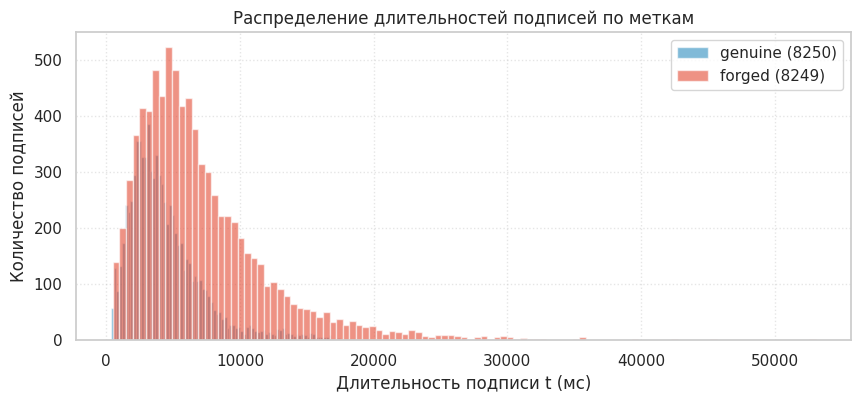

In [ ]:
# 📊 Визуализация распределения t для LMDB
from analysis import plot_t_distribution_by_label

fig, text = plot_t_distribution_by_label(LMDB_PATH, bin_width=500, text_step=100, overlay=True)
fig.show()
print(text)

In [ ]:
# 🔍 Поиск неподрезанных подписей с мусорными точками
from analysis import find_untrimmed_signatures

problematic = find_untrimmed_signatures(LMDB_PATH, max_skip_check=10)
print(f"Найдено {len(problematic)} подозрительных подписей")
# Выведем первые 10 результатов
for rec in problematic[:10]:
    print(rec)
